In [88]:
import pandas as pd
df_order = pd.read_csv("/content/sample_data/order.csv")
df_customer = pd.read_csv("/content/sample_data/customer.csv")
df_product = pd.read_csv("/content/sample_data/product.csv")
df_location = pd.read_csv("/content/sample_data/location.csv")

print(df_order.columns.tolist())
print(df_customer.columns.tolist())
print(df_product.columns.tolist())
print(df_location.columns.tolist())

['OrderID', 'CustomerID', 'ProductID', 'OrderDate', 'Quantity', 'OrderStatus', 'PaymentMethod', 'Sales']
['CustomerID', 'CustomerName', 'Age', 'Gender', 'LocationID']
['ProductID', 'ProductName', 'Category', 'UnitPrice']
['LocationID', 'City', 'State', 'Region']


In [89]:
combined = df_order.merge(
    df_customer,
    on="CustomerID",
    how="left"
)
combined = combined.merge(
    df_product,
    on="ProductID",
    how="left"
)
combined = combined.merge(
    df_location,
    on="LocationID",
    how="left"
)

print(combined.shape)

(105, 18)


In [90]:
#check duplicates
combined = combined.drop_duplicates()

In [91]:
#check missing vlues
if combined.isnull().values.any():
  combined = combined.dropna(axis=1)


In [92]:
# check the inconsistent categories
combined.columns = (
    combined.columns.str.strip().str.lower()
    )
combined

,orderid,customerid,productid,orderdate,orderstatus,paymentmethod,customername,gender,locationid,productname,category,city,state,region
0,O0001,C037,P022,2026-01-01,Completed,Net Banking,Meera Bhosale,Female,L009,Laptop Stand,Electronics,Thane,Maharashtra,West
1,O0002,C033,P024,2026-01-02,Cancelled,Debit Card,Sneha Jadhav,Male,L007,Wireless Charger,Accessories,Akola,Maharashtra,Vidarbha
2,O0003,C042,P001,2026-01-03,Shipped,Debit Card,Vivaan Kulkarni,Female,L013,Laptop,Audio,Satara,Maharashtra,West
3,O0004,C044,P024,2026-01-04,Completed,UPI,Arjun Shinde,Male,L003,Wireless Charger,Accessories,Nashik,Maharashtra,North
4,O0005,C024,P020,2026-01-05,Refunded,Cash on Delivery,Arjun Shinde,Male,L012,USB Hub,Audio,Sangli,Maharashtra,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,O0096,C048,P020,2026-04-06,Completed,Net Banking,Kunal Patil,Female,L011,USB Hub,Audio,Amravati,Maharashtra,Vidarbha
99,O0097,C016,P029,2026-04-07,Refunded,Net Banking,Kavya Pawar,Female,L013,Backpack,Electronics,Satara,Maharashtra,West
100,O0098,C003,P021,2026-04-08,Shipped,Net Banking,Aditya Jadhav,Female,L013,HDMI Cable,Mobile,Satara,Maharashtra,West
101,O0099,C020,P023,2026-04-09,Completed,Debit Card,Simran More,Male,L006,Phone Case,Audio,Nanded,Maharashtra,Marathwada


In [93]:
#handle refunds
combined['orderstatus'].value_counts()
refunds = df_order[df_order['OrderStatus'].str.lower() == 'refunded']
print("Number of refunds:", len(refunds))

Number of refunds: 12


In [94]:
print(combined.columns.tolist())
print(combined["customerid"].dtype)
print(combined["orderid"].dtype)

['orderid', 'customerid', 'productid', 'orderdate', 'orderstatus', 'paymentmethod', 'customername', 'gender', 'locationid', 'productname', 'category', 'city', 'state', 'region']
object
object


In [95]:
print(combined.columns.tolist())


['orderid', 'customerid', 'productid', 'orderdate', 'orderstatus', 'paymentmethod', 'customername', 'gender', 'locationid', 'productname', 'category', 'city', 'state', 'region']


In [96]:
#revenue
combined["revenue"] = df_order["Quantity"] * df_product["UnitPrice"]
revenue = combined["revenue"].sum()

#oders
order = combined["orderid"].nunique()

#Aversge oder value
aov = revenue / order

#repeat customer rate
customer_order = combined.groupby("customerid")["orderid"].nunique()
#print(customer_order.dtype)

repeat_customer = (customer_order > 1).sum()
total_customer = combined["customerid"].nunique()
repeat_customer_rate = (repeat_customer/total_customer) *100

# Margin (only if Cost column exists)
if "Cost" in combined.columns:
  combined["Cost_Total"] = combined["Quantity"] * combined["Cost"]
  combined["Margin"] = combined["Revenue"] - combined["Cost_Total"]
  margin = combined["Margin"].sum()
  margin_percentage = (margin / revenue) * 100

  print("Revenue:", round(revenue, 2))
  print("Orders:", order)
  print("Average Order Value:", round(aov, 2))
  print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")
  print("Margin:", round(margin, 2))
  print("Margin %:", round(margin_percentage, 2), "%")

else:
  print("Revenue:", round(revenue, 2))
  print("Orders:", order)
  print("Average Order Value:", round(aov, 2))
  print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")
  print("Margin: Cost column not available")



Revenue: 446328.0
Orders: 100
Average Order Value: 4463.28
Repeat Customer Rate: 70.0 %
Margin: Cost column not available


In [97]:
combined["orderdate"] = pd.to_datetime(combined["orderdate"])
combined["month"] = combined["orderdate"].dt.to_period("M")
monthly_order = combined.groupby("month")["orderid"].nunique()
print(monthly_order)

month
2026-01    31
2026-02    28
2026-03    31
2026-04    10
Freq: M, Name: orderid, dtype: int64


<Axes: title={'center': 'Monthly Order Trend'}, xlabel='month'>

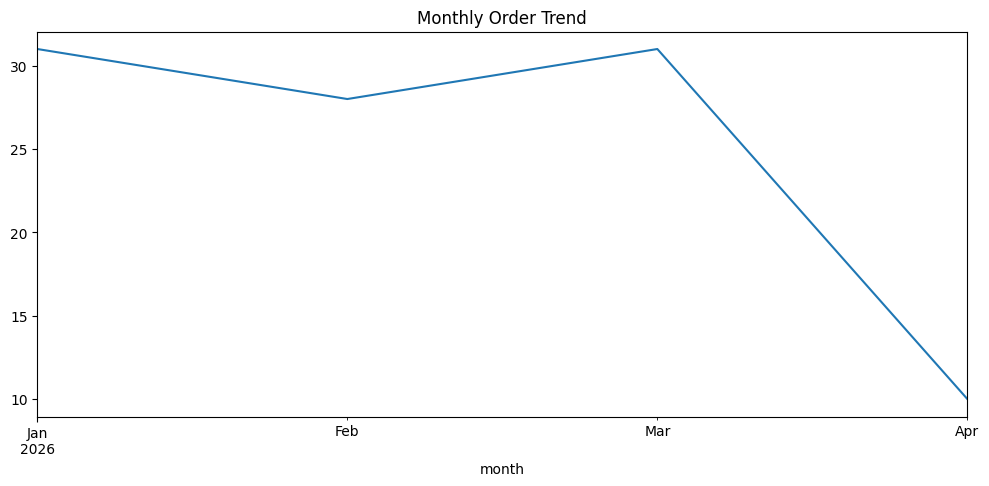

In [98]:
monthly_order.plot(
    kind="line",
    figsize=(12,5),
    title="Monthly Order Trend"
)

In [99]:
monthly_customer = combined.groupby("month")["customerid"].nunique()
print(monthly_customer)

month
2026-01    18
2026-02    21
2026-03    27
2026-04    10
Freq: M, Name: customerid, dtype: int64


In [100]:
customer_behavior = (
    combined.groupby("customerid")
    .agg(
        total_orders=("orderid", "nunique"),
        first_order=("orderdate", "min"),
        last_order=("orderdate", "max")
    )
    .reset_index()
)

In [101]:
def segment_customer(orders):
    if orders == 1:
        return "One-time Customer"
    elif orders <= 3:
        return "Occasional Customer"
    else:
        return "Frequent Customer"

customer_behavior["segment"] = customer_behavior["total_orders"].apply(
    segment_customer
)

In [102]:
print(customer_behavior["segment"].value_counts())

segment
Occasional Customer    18
One-time Customer      12
Frequent Customer      10
Name: count, dtype: int64


In [103]:
top_products = (
    combined.groupby("productname")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print(top_products.head(10))

productname
Laptop                 8
Keyboard               7
Backpack               6
Desk Lamp              5
Mechanical Keyboard    5
Laptop Stand           5
HDMI Cable             5
Microphone             5
Office Chair           5
Smartwatch             5
Name: orderid, dtype: int64


<Axes: title={'center': 'Top 10 Products by Orders'}, xlabel='productname'>

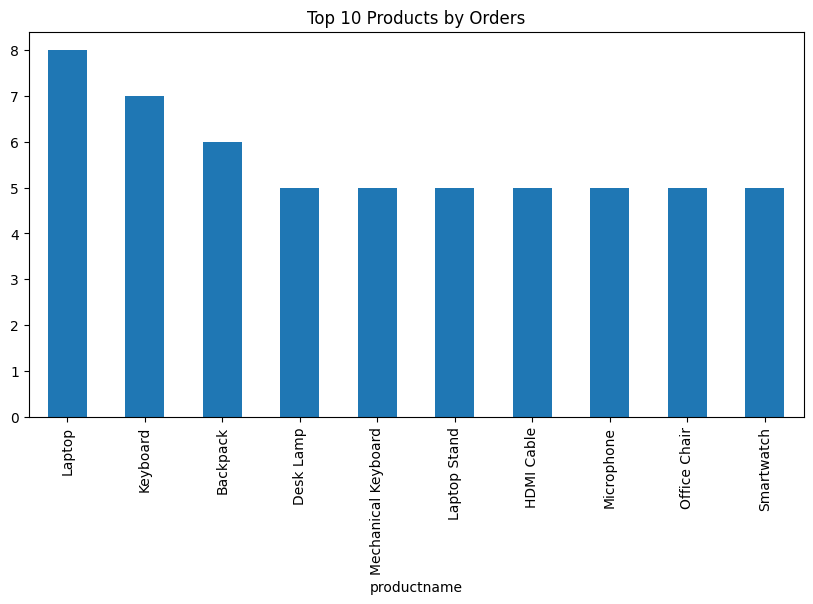

In [104]:
top_products.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Products by Orders"
)

In [105]:
category_performance = (
    combined.groupby("category")["orderid"]
    .nunique()
    .sort_values()
)

print(category_performance)

category
ELECTRONICS       2
 electronics      4
Office           10
Accessories      12
Mobile           14
Electronics      16
Computers        19
Audio            23
Name: orderid, dtype: int64


In [106]:
high_frequency_customers = (
    combined.groupby(["customerid", "customername"])["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print(high_frequency_customers.head(10))

customerid  customername   
C032        Ananya Kulkarni    7
C049        Sahil Joshi        6
C002        Vivaan Kulkarni    5
C003        Aditya Jadhav      4
C019        Tanvi Joshi        4
C016        Kavya Pawar        4
C037        Meera Bhosale      4
C033        Sneha Jadhav       4
C024        Arjun Shinde       4
C048        Kunal Patil        4
Name: orderid, dtype: int64


In [107]:
regional_orders = (
    combined.groupby("region")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print(regional_orders)

region
West          44
Vidarbha      24
North         14
East           6
Marathwada     6
Central        4
South          2
Name: orderid, dtype: int64


In [108]:
state_orders = (
    combined.groupby("state")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print(state_orders)

state
Maharashtra    100
Name: orderid, dtype: int64


In [109]:
city_orders = (
    combined.groupby("city")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print(city_orders.head(10))

city
Thane         20
Akola         15
Satara        13
Amravati       9
Jalgaon        9
Sangli         8
Nagpur         6
Nanded         5
Nashik         5
Aurangabad     4
Name: orderid, dtype: int64


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# DATE CLEANING
# -------------------------

combined["orderdate"] = pd.to_datetime(combined["orderdate"])

combined["month"] = combined["orderdate"].dt.to_period("M")


# -------------------------
# KPIs
# -------------------------

total_orders = combined["orderid"].nunique()
total_customers = combined["customerid"].nunique()

customer_orders = combined.groupby("customerid")["orderid"].nunique()

repeat_customers = (customer_orders > 1).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("========== KPIs ==========")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:",
      round(repeat_customer_rate, 2), "%")

print("Revenue: Not available")
print("Average Order Value: Not available")
print("Margin: Not available")


# -------------------------
# MONTHLY TREND
# -------------------------

monthly_orders = (
    combined.groupby("month")["orderid"]
    .nunique()
)

print("\n========== Monthly Orders ==========")
print(monthly_orders)


# -------------------------
# CUSTOMER SEGMENTATION
# -------------------------

customer_behavior = (
    combined.groupby("customerid")
    .agg(
        total_orders=("orderid", "nunique"),
        first_order=("orderdate", "min"),
        last_order=("orderdate", "max")
    )
    .reset_index()
)

def segment_customer(orders):
    if orders == 1:
        return "One-time Customer"
    elif orders <= 3:
        return "Occasional Customer"
    else:
        return "Frequent Customer"

customer_behavior["segment"] = (
    customer_behavior["total_orders"]
    .apply(segment_customer)
)

print("\n========== Customer Segments ==========")
print(customer_behavior["segment"].value_counts())


# -------------------------
# TOP PRODUCTS
# -------------------------

top_products = (
    combined.groupby("productname")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print("\n========== Top Products ==========")
print(top_products.head(10))


# -------------------------
# CATEGORY PERFORMANCE
# -------------------------

category_performance = (
    combined.groupby("category")["orderid"]
    .nunique()
    .sort_values()
)

print("\n========== Category Performance ==========")
print(category_performance)


# -------------------------
# HIGH-FREQUENCY CUSTOMERS
# -------------------------

high_frequency_customers = (
    combined.groupby(
        ["customerid", "customername"]
    )["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print("\n========== High-Frequency Customers ==========")
print(high_frequency_customers.head(10))


# -------------------------
# REGIONAL ANALYSIS
# -------------------------

regional_orders = (
    combined.groupby("region")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print("\n========== Regional Orders ==========")
print(regional_orders)


# -------------------------
# STATE ANALYSIS
# -------------------------

state_orders = (
    combined.groupby("state")["orderid"]
    .nunique()
    .sort_values(ascending=False)
)

print("\n========== State Orders ==========")
print(state_orders)

========== KPIs ==========
Total Orders: 100
Total Customers: 40
Repeat Customers: 28
Repeat Customer Rate: 70.0 %
Revenue: Not available
Average Order Value: Not available
Margin: Not available

========== Monthly Orders ==========
month
2026-01    31
2026-02    28
2026-03    31
2026-04    10
Freq: M, Name: orderid, dtype: int64

========== Customer Segments ==========
segment
Occasional Customer    18
One-time Customer      12
Frequent Customer      10
Name: count, dtype: int64

========== Top Products ==========
productname
Laptop                 8
Keyboard               7
Backpack               6
Desk Lamp              5
Mechanical Keyboard    5
Laptop Stand           5
HDMI Cable             5
Microphone             5
Office Chair           5
Smartwatch             5
Name: orderid, dtype: int64

========== Category Performance ==========
category
ELECTRONICS       2
 electronics      4
Office           10
Accessories      12
Mobile           14
Electronics      16
Computers       